# Visit-count confound diagnostics (SANITY)

Reloads a previously trained longitudinal trajectory model (the `latest/` run of `SOURCE_EXPERIMENT`) **without retraining** and quantifies the *converters-have-fewer-visits* confound. Model-agnostic: every model-specific operation goes through the adapter hooks (`adapters/`), all computation lives in `common/visit_confound.py`.

Driven by `run_experiment.py` via the `sanity-visit-confound-*` entries in `experiments.yaml`. See `common/VISIT_COUNT_CONFOUND.md` for the interpretation.

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                # adapter registry key; None -> defaults to MODEL
DATASET = None
SEED = 42
SOURCE_EXPERIMENT = None      # id whose outputs/<id>/latest/ run is reloaded
WANDB_ENABLED = True
OUTPUT_DIR = None
RESOLVED_CONFIG = None
RUN_DIR = None                # set by the runner: where artifacts go
RUN_NAME = None               # set by the runner: the run name

In [2]:
# Parameters
EXPERIMENT_ID = "sanity-visit-confound-gec"
MODE = "sanity"
MODEL = "GEC"
ADAPTER = "gec"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = None
SOURCE_EXPERIMENT = "gec-trajectory-whole-brain"
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/sanity-visit-confound-gec"
RESOLVED_CONFIG = {"epochs": 100, "lr": 0.001, "batch_size": 32, "grad_clip": 1.0, "early_stopping_patience": 20, "use_scheduler": True, "seed": 42, "wandb_project": "ad-early-detection", "wandb_enabled": True, "threshold_mode": "youden", "fixed_threshold": 0.5, "lr_factor": 0.5, "lr_patience": 5, "lr_min": 1e-06}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/sanity-visit-confound-gec/runs/noble-river-1-d9655b0db-2026-06-21_02-01-19"
RUN_NAME = "noble-river-1-d9655b0db-2026-06-21_02-01-19"


In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# reproducibility seeding — must run before datasets or models.
from CLASSIFIER.common.seeding import set_seed, make_rng, make_torch_generator
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

In [5]:
import json, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datetime import datetime

from common.sanity import run_full_audit
from common.provenance import region_from_data_root
from common.crossval import Bundle
from common.early_detection import early_detection_table, trajectory_frame
from common.visit_confound import (
    summarize_visit_counts, cohort_composition_table, early_detection_fixed_cohort,
    prob_vs_visit_count, prob_spread_summary,
)
from adapters import get_adapter, read_run_threshold
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuration

In [7]:
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts.csv')
SPLITS_DIR   = str(splits_dir('downstream'))
TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')
DATA_INFO    = region_from_data_root(WB_DATA_ROOT)
REGION       = DATA_INFO['region']
CONFIG_PATH  = model_root / 'configs' / 'gaae_delcode_whole_brain.json'
print(f"Region: {REGION}  atlas={DATA_INFO['atlas']}")

Region: wholebrain  atlas=sch200


In [8]:
# split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('downstream'))

[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Resolve source run

Reload the `latest/` run of `SOURCE_EXPERIMENT`: its `run_summary.json` gives the GAAE checkpoint + the exact `training_config` the model was trained with (so the adapter is rebuilt identically — `rnn_type`, `use_fdr`, … all match).

In [9]:
if not SOURCE_EXPERIMENT:
    raise ValueError(
        "SANITY_VISIT_COUNT_CONFOUND requires SOURCE_EXPERIMENT; set "
        "'source_experiment:' on the entry in experiments.yaml."
    )
src_root = model_root / 'outputs' / SOURCE_EXPERIMENT
latest = src_root / 'latest'
if latest.exists():
    SRC_RUN_DIR = latest.resolve()
elif (src_root / 'latest.txt').is_file():
    SRC_RUN_DIR = src_root / 'runs' / (src_root / 'latest.txt').read_text().strip()
else:
    raise FileNotFoundError(f'No latest run for {SOURCE_EXPERIMENT!r} under {src_root}.')
if not SRC_RUN_DIR.is_dir():
    raise FileNotFoundError(f'Resolved source run dir missing: {SRC_RUN_DIR}')
print('Source run:', SRC_RUN_DIR)

with open(SRC_RUN_DIR / 'run_summary.json') as f:
    SRC_SUMMARY = json.load(f)
SRC_TRAIN_CONFIG = dict(SRC_SUMMARY.get('training_config') or {})
SRC_MODEL_CONFIG = dict(SRC_SUMMARY.get('model_config') or {})
GAAE_CKPT_PATH = SRC_SUMMARY.get('gaae_checkpoint')
if not GAAE_CKPT_PATH or not Path(GAAE_CKPT_PATH).exists():
    raise FileNotFoundError(f'GAAE checkpoint from source run not found: {GAAE_CKPT_PATH}')
print('training_config keys:', sorted(SRC_TRAIN_CONFIG))
print('GAAE checkpoint   :', GAAE_CKPT_PATH)

Source run: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gec-trajectory-whole-brain/runs/dainty-totem-7-eb1a07a3a-2026-06-21_01-07-28
training_config keys: ['adjacency_k', 'append_visit_mask', 'batch_size', 'early_stopping_patience', 'epochs', 'file_variant', 'fixed_threshold', 'grad_clip', 'learning_rate', 'lr', 'lr_factor', 'lr_min', 'lr_patience', 'max_visits', 'mlp_dropout', 'mlp_hidden_layers', 'n_folds', 'seed', 'threshold_mode', 'use_scheduler', 'use_time_delta', 'wandb_enabled', 'wandb_project']
GAAE checkpoint   : /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth


In [10]:
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f: hp = json.load(f)
else:
    hp = dict(latent_dim=64, hidden_dim=128, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
print('GAAE config:', hp)

GAAE config: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001, 'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25, 'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'}


## Rebuild adapter + reload trained model

In [11]:
adapter = get_adapter(ADAPTER or MODEL)(
    gaae_ckpt_path=str(GAAE_CKPT_PATH), gaae_hp=hp, train_config=SRC_TRAIN_CONFIG,
    data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=rng,
)
print('Adapter:', type(adapter).__name__, ' model_tag=', adapter.model_tag)
prepare_data         = adapter.prepare_data
eval_split           = adapter.eval_split
truncate_to_n_visits = adapter.truncate_to_n_visits
per_visit_probs      = adapter.per_visit_probs

Adapter: GECAdapter  model_tag= gec


In [12]:
train_df = pd.read_csv(TRAIN_CSV); val_df = pd.read_csv(VAL_CSV); test_df = pd.read_csv(TEST_CSV)
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
CV_BUNDLE   = prepare_data(cv_pool_df)   # encodes CV pool first (locks GEC max_visits)
TEST_BUNDLE = prepare_data(test_df)
_all_items  = list(CV_BUNDLE.items) + list(TEST_BUNDLE.items)
ALL_BUNDLE  = Bundle([it['label'] for it in _all_items],
                     [it['subject_id'] for it in _all_items], _all_items)
print(f'CV subjects: {len(CV_BUNDLE)}  Test subjects: {len(TEST_BUNDLE)}  All: {len(ALL_BUNDLE)}')

LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=3.0


GEC: MAX_VISITS=6  k=64  feat_dim=396
LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


CV subjects: 133  Test subjects: 34  All: 167


In [13]:
STATE = adapter.load_state(SRC_RUN_DIR)
THRESHOLD = read_run_threshold(SRC_RUN_DIR)
print(f'Reloaded model state; threshold = {THRESHOLD:.4f}')

# Cross-check: reloaded test AUC must match the saved run (else the reload is wrong).
_chk = eval_split(STATE, TEST_BUNDLE, THRESHOLD, device=device)
_saved = (SRC_SUMMARY.get('metrics') or {}).get('test_auc', SRC_SUMMARY.get('test_auc'))
print(f"Reloaded test AUC = {_chk['auc']:.4f}   (saved: {_saved})")

Reloaded model state; threshold = 0.6536
Reloaded test AUC = 0.9643   (saved: 0.9642857142857143)


## 1 — Do converters have fewer visits?

In [14]:
VC_ALL  = summarize_visit_counts(ALL_BUNDLE)
VC_TEST = summarize_visit_counts(TEST_BUNDLE)
print('Visit counts by group — full mci/converter dataset:')
display(VC_ALL)
print('Visit counts by group — held-out test split:')
display(VC_TEST)

Visit counts by group — full mci/converter dataset:


,group,n,mean,median,std,min,max,mwu_pvalue
0,converter,68,3.426471,3.0,1.459055,1,6,0.002204
1,non_converter,99,2.737374,2.0,1.619939,1,6,0.002204
2,overall,167,3.017964,3.0,1.588638,1,6,0.002204


Visit counts by group — held-out test split:


,group,n,mean,median,std,min,max,mwu_pvalue
0,converter,14,3.714286,3.5,1.489893,2,6,0.011002
1,non_converter,20,2.350000,2.0,1.182103,1,4,0.011002
2,overall,34,2.911765,3.0,1.464068,1,6,0.011002


## 2 — Per-N cohort composition vs the early-detection AUC

The variable-cohort early-detection table re-scores a *shrinking, self-selected* cohort at each N. The composition columns show how the class balance shifts, which is why per-N AUCs are not directly comparable.

In [15]:
ED_VAR  = early_detection_table(TEST_BUNDLE, eval_split, truncate_to_n_visits,
                                STATE, THRESHOLD, device=device)
COMP    = cohort_composition_table(TEST_BUNDLE, truncate_to_n_visits)
ed_df   = pd.DataFrame(ED_VAR)
comp_df = pd.DataFrame(COMP)
COMBINED = comp_df.merge(ed_df[['n_visits', 'auc', 'sensitivity', 'specificity']],
                         on='n_visits', how='left') if not ed_df.empty else comp_df
print('Per-N cohort composition + variable-cohort AUC:')
display(COMBINED)


Visits    N      AUC     Sens     Spec
----------------------------------------
     1   34   0.5643    0.143    0.850
     2   28   0.9286    0.857    0.714
     3   18   0.9500    0.900    1.000
     4   12   0.9143    0.857    1.000
Per-N cohort composition + variable-cohort AUC:


,n_visits,n_subjects,n_converters,n_nonconverters,frac_converter,auc,sensitivity,specificity
0,1,34,14,20,0.411765,0.564286,0.142857,0.850000
1,2,28,14,14,0.500000,0.928571,0.857143,0.714286
2,3,18,10,8,0.555556,0.950000,0.900000,1.000000
3,4,12,7,5,0.583333,0.914286,0.857143,1.000000
4,5,5,5,0,1.000000,NaN,NaN,NaN
5,6,2,2,0,1.000000,NaN,NaN,NaN


## 3 — Fixed-cohort early detection

Restrict to the deepest-followed subjects (observed at every N) and truncate *them* to N=1..max. The cohort no longer changes, so this trend reflects information per visit, not a changing population. The fixed cohort can be small — read `n_subjects`.


Visits    N      AUC     Sens     Spec
----------------------------------------
Fixed-cohort early detection:


""


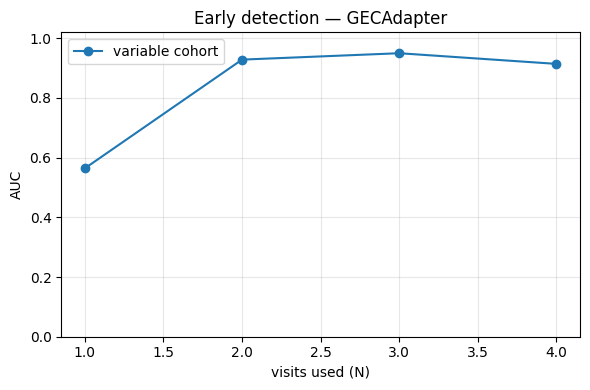

In [16]:
ED_FIXED = early_detection_fixed_cohort(TEST_BUNDLE, eval_split, truncate_to_n_visits,
                                        STATE, THRESHOLD, device=device)
fixed_df = pd.DataFrame(ED_FIXED)
print('Fixed-cohort early detection:')
display(fixed_df)

fig_ed, ax = plt.subplots(figsize=(6, 4))
if not ed_df.empty:
    ax.plot(ed_df['n_visits'], ed_df['auc'], 'o-', label='variable cohort')
if not fixed_df.empty:
    ax.plot(fixed_df['n_visits'], fixed_df['auc'], 's--', label='fixed cohort')
ax.set_xlabel('visits used (N)'); ax.set_ylabel('AUC'); ax.set_ylim(0, 1.02)
ax.set_title(f'Early detection — {type(adapter).__name__}'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4 — Does the model read visit count? (prediction vs n_scans)

Full-trajectory P(converter) against the number of visits. A correlation that survives *within* a label is the shortcut signal — the model using visit count rather than biology.

Spearman r(prob, n_scans):
  overall        r=0.169  p=0.340  n=34
  converter      r=0.101  p=0.731  n=14
  non_converter  r=-0.480  p=0.032  n=20


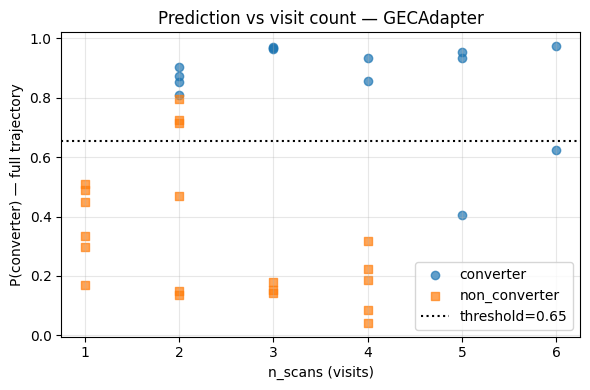

In [17]:
PROB_DF, SPEARMAN = prob_vs_visit_count(TEST_BUNDLE, per_visit_probs, STATE, device=device)
print('Spearman r(prob, n_scans):')
for grp, s in SPEARMAN.items():
    print(f"  {grp:14s} r={s['r']:.3f}  p={s['p']:.3f}  n={s['n']}")

fig_prob, ax = plt.subplots(figsize=(6, 4))
for lab in (1, 0):
    sub = PROB_DF[PROB_DF['label'] == lab]
    ax.scatter(sub['n_scans'], sub['prob'], marker=('o' if lab == 1 else 's'),
               label=('converter' if lab == 1 else 'non_converter'), alpha=0.7)
ax.axhline(THRESHOLD, ls=':', c='k', label=f'threshold={THRESHOLD:.2f}')
ax.set_xlabel('n_scans (visits)'); ax.set_ylabel('P(converter) — full trajectory')
ax.set_title(f'Prediction vs visit count — {type(adapter).__name__}')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5 — Probability spread / separation

In [18]:
TRAJ_DF = trajectory_frame(TEST_BUNDLE, per_visit_probs, STATE, device=device)
SPREAD_FINAL = prob_spread_summary(PROB_DF)
SPREAD_TRAJ  = prob_spread_summary(TRAJ_DF)
print('Spread — full-trajectory prediction:'); print(json.dumps(SPREAD_FINAL, indent=2))
print('Spread — all per-visit predictions:'); print(json.dumps(SPREAD_TRAJ, indent=2))

Spread — full-trajectory prediction:
{
  "converter": {
    "n": 14,
    "mean": 0.8586438596248627,
    "std": 0.1597619926843057,
    "iqr": 0.10626834630966187
  },
  "non_converter": {
    "n": 20,
    "mean": 0.3285020854324102,
    "std": 0.22636445498115468,
    "iqr": 0.32235685735940933
  },
  "overall": {
    "n": 34,
    "mean": 0.5467957571587142,
    "std": 0.3312016220847924,
    "iqr": 0.673743300139904
  },
  "separation": 0.5301417741924525
}
Spread — all per-visit predictions:
{
  "converter": {
    "n": 52,
    "mean": 0.7230607456026169,
    "std": 0.2643418628225559,
    "iqr": 0.39131754636764526
  },
  "non_converter": {
    "n": 41,
    "mean": 0.3597485544841464,
    "std": 0.228773151858415,
    "iqr": 0.3299693316221237
  },
  "overall": {
    "n": 93,
    "mean": 0.562890854894474,
    "std": 0.30721683476896766,
    "iqr": 0.5786325931549072
  },
  "separation": 0.3633121911184705
}


## Save diagnostics

In [19]:
CONFOUND = {
    'experiment_id': EXPERIMENT_ID, 'source_experiment': SOURCE_EXPERIMENT,
    'source_run_dir': str(SRC_RUN_DIR), 'model': type(adapter).__name__,
    'threshold': float(THRESHOLD),
    'visit_counts_all': VC_ALL.to_dict('records'),
    'visit_counts_test': VC_TEST.to_dict('records'),
    'cohort_composition': COMP,
    'early_detection_variable': ED_VAR,
    'early_detection_fixed': ED_FIXED,
    'prob_vs_visit_count_spearman': SPEARMAN,
    'prob_spread_final': SPREAD_FINAL,
    'prob_spread_trajectory': SPREAD_TRAJ,
}
out_dir = Path(RUN_DIR) if RUN_DIR else (
    model_root / 'outputs' / (EXPERIMENT_ID or 'sanity-visit-confound') / 'standalone')
out_dir.mkdir(parents=True, exist_ok=True)
with open(out_dir / 'confound_results.json', 'w') as f:
    json.dump(CONFOUND, f, indent=2)
fig_ed.savefig(out_dir / 'early_detection_fixed_vs_variable.png', dpi=120, bbox_inches='tight')
fig_prob.savefig(out_dir / 'prob_vs_visit_count.png', dpi=120, bbox_inches='tight')

def _mean(recs, grp):
    return next((r['mean'] for r in recs if r['group'] == grp), float('nan'))
conv_gap = _mean(CONFOUND['visit_counts_all'], 'converter') - _mean(CONFOUND['visit_counts_all'], 'non_converter')
summary = {
    'experiment_id': EXPERIMENT_ID, 'run_name': RUN_NAME,
    'source_experiment': SOURCE_EXPERIMENT,
    'timestamp': datetime.now().isoformat(timespec='seconds'),
    'metrics': {
        'converter_visit_count_gap': float(conv_gap),
        'visit_count_mwu_pvalue': float(CONFOUND['visit_counts_all'][0]['mwu_pvalue']),
        'prob_nscans_spearman_overall': float(SPEARMAN['overall']['r']),
        'prob_nscans_spearman_converter': float(SPEARMAN['converter']['r']),
        'early_detection_auc_max_variable': float(max((r['auc'] for r in ED_VAR), default=float('nan'))),
        'early_detection_auc_max_fixed': float(max((r['auc'] for r in ED_FIXED), default=float('nan'))),
        'prob_separation': float(SPREAD_FINAL['separation']),
    },
}
with open(out_dir / 'run_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved confound diagnostics to', out_dir)

Saved confound diagnostics to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/sanity-visit-confound-gec/runs/noble-river-1-d9655b0db-2026-06-21_02-01-19
